In [1]:
# Create an environment for this.

# Indoor Temperature Prediction using Netatmo Weather Data

# This notebook trains a simple neural network to predict indoor temperature from Netatmo weather station measurements.

# Features used:
# - Outdoor temperature
# - Outdoor humidity
# - Time-of-day and seasonal time features
# - Previous indoor temperature measurements (lag features)

# The data is split chronologically into training, validation, and test periods to avoid information leakage from future observations. A small feed-forward neural network is trained and evaluated, and the predicted indoor temperatures are compared against the measured values on the test period.

# Goal:
# - Explore the predictability of indoor temperature
# - Capture the thermal inertia of the house using historical indoor measurements
# - Establish a baseline model for future time-series models such as LSTMs or other sequence-based neural networks

# ============================================================
# Results and Discussion
# ============================================================
#
# Several baseline models were evaluated for indoor temperature
# prediction using outdoor weather measurements, time features,
# and historical indoor temperature measurements.
#
# Test-set results:
#
#   Persistence         MAE = 0.0387 °C   RMSE = 0.0866 °C
#   Linear Regression   MAE = 0.0624 °C   RMSE = 0.0889 °C
#   Ridge Regression    MAE = 0.0625 °C   RMSE = 0.0891 °C
#   Neural Network      MAE = 1.3825 °C   RMSE = 1.4727 °C
#
# Observations:
#
# 1. The persistence baseline achieved the best performance.
#    Simply predicting that the indoor temperature remains equal
#    to the previous measurement resulted in the lowest error.
#
# 2. Linear and Ridge regression produced slightly worse
#    performance than persistence but remained within the same
#    order of magnitude.
#
# 3. The neural network performed significantly worse than all
#    baseline models, indicating that it failed to learn a useful
#    representation of the problem in its current configuration.
#
# 4. The strong performance of the persistence baseline suggests
#    that short-term indoor temperature prediction is dominated by
#    thermal inertia. Over a 5-minute prediction horizon, indoor
#    temperature changes only very slowly, making the previous
#    indoor temperature an extremely strong predictor.
#
# Conclusion:
#
# The current prediction task is largely solved by knowledge of
# recent indoor temperature measurements. The predictive value of
# the outdoor measurements is comparatively small when historical
# indoor temperatures are available.
#
# ============================================================
# Next Step
# ============================================================
#
# To investigate how much information is contained in the outdoor
# measurements alone, the next experiment will remove all indoor
# temperature lag features from the input data.
#
# The model will then attempt to predict indoor temperature using:
#
#   - Current outdoor temperature
#   - Current outdoor humidity
#   - Historical outdoor temperature measurements
#   - Historical outdoor humidity measurements
#   - Time-of-day features
#   - Seasonal features
#
# This setup is more challenging because the model must infer the
# thermal state of the building indirectly from weather history
# rather than being given the recent indoor temperature directly.
#
# The resulting performance will provide insight into how strongly
# indoor temperature can be estimated from external conditions
# alone and how much thermal memory is captured by the outdoor
# measurements.
#
# ============================================================

In [2]:
## Imports

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input

plt.style.use("default")
sns.set_theme()

%matplotlib inline

2026-06-24 10:05:35.921609: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-24 10:05:35.959457: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-24 10:05:35.959499: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-24 10:05:35.962259: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-24 10:05:35.975186: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-24 10:05:35.976351: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [3]:
## Find all Weather.csv files

DATA_ROOT = Path("../data/csv")

weather_files = sorted(DATA_ROOT.glob("*/Weather.csv"))

print(f"Found {len(weather_files)} weather files:\n")

for i, f in enumerate(weather_files):
    print(f"{i}: {f.parent.name}")

Found 3 weather files:

0: Huis_19_06_2026_30min
1: Huis_19_06_2026_all
2: Huis_may_2025


In [4]:
## Loader

def load_weather_file(path):
    """
    Load Netatmo-style Weather.csv export.
    """

    df = pd.read_csv(
        path,
        skiprows=5,
        sep=",",
        engine="python"
    )

    df.columns = [str(c).strip() for c in df.columns]

    rename_map = {
        "Timezone : Europe/Amsterdam": "datetime",
    }

    df = df.rename(columns=rename_map)

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])

    return df

In [5]:
## Load data

path = weather_files[2]

df = load_weather_file(path)

print(path.parent.name)

df.head()

Huis_may_2025


,Timestamp,datetime,Temperature °C,Humidity %,CO2 ppm,Noise dB,Pressure Pa,Unnamed: 7,Temperature °C.1,Humidity %.1,Unnamed: 10
0,1745964150,2025-04-30 00:02:30,22.3,52,1168,32,1022.7,NaN,14.1,80.0,NaN
1,1745964450,2025-04-30 00:07:30,22.3,52,1168,32,1022.7,NaN,14.2,80.0,NaN
2,1745964750,2025-04-30 00:12:30,22.2,52,1168,32,1022.7,NaN,14.1,80.0,NaN
3,1745965050,2025-04-30 00:17:30,22.3,52,1141,33,1022.7,NaN,14.1,80.0,NaN
4,1745965350,2025-04-30 00:22:30,22.2,52,1141,34,1022.7,NaN,14.1,81.0,NaN


In [6]:
## Inspect columns

print(df.columns.tolist())

['Timestamp', 'datetime', 'Temperature °C', 'Humidity %', 'CO2 ppm', 'Noise dB', 'Pressure Pa', 'Unnamed: 7', 'Temperature °C.1', 'Humidity %.1', 'Unnamed: 10']


In [7]:
## Rename columns

df = df.rename(
    columns={
        "Temperature °C": "temp_in",
        "Humidity %": "hum_in",
        "Temperature °C.1": "temp_out",
        "Humidity %.1": "hum_out",
    }
)

# Only keep those values
df = df[
    [
        "datetime",
        "temp_in",
        "hum_in",
        "temp_out",
        "hum_out",
    ]
]

df = df.sort_values("datetime")

df.head()

,datetime,temp_in,hum_in,temp_out,hum_out
0,2025-04-30 00:02:30,22.3,52,14.1,80.0
1,2025-04-30 00:07:30,22.3,52,14.2,80.0
2,2025-04-30 00:12:30,22.2,52,14.1,80.0
3,2025-04-30 00:17:30,22.3,52,14.1,80.0
4,2025-04-30 00:22:30,22.2,52,14.1,81.0


In [8]:
## Create time features

df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dayofyear"] = df["datetime"].dt.dayofyear

df["day_sin"] = np.sin(
    2 * np.pi * df["dayofyear"] / 365.25
)

df["day_cos"] = np.cos(
    2 * np.pi * df["dayofyear"] / 365.25
)

In [9]:
## Create lag features for inside and outside temperatures

# Number of historical measurements to include.
# Netatmo records are sampled every 5 minutes, so:
# 12 lags = 12 × 5 min = 60 minutes of history.
INDOOR_LAGS = 48
OUTDOOR_LAGS = 48
# Indoor temperature lags
#
# Indoor temperature exhibits strong thermal inertia:
# the current indoor temperature is usually highly correlated
# with temperatures measured during the previous hour.
#
# These lag features provide the model with a short-term memory
# of the recent indoor temperature evolution.
for lag in range(1, INDOOR_LAGS + 1):
    df[f"temp_in_lag_{lag}"] = df["temp_in"].shift(lag)

# Outdoor temperature lags
#
# Changes in outdoor temperature do not immediately affect the
# indoor climate. Heat transfer through walls, windows, ventilation,
# and the thermal mass of the building introduces a delay.
#
# By including previous outdoor temperatures, the model can learn
# these delayed effects and better capture the building's thermal
# response to changing weather conditions.
for lag in range(1, OUTDOOR_LAGS + 1):
    df[f"temp_out_lag_{lag}"] = df["temp_out"].shift(lag)

# Remove rows for which one or more lag values are unavailable.
# The first N_LAGS rows cannot have a complete history because
# there are not enough previous observations.
df = df.dropna()

print(df.shape)

(8672, 108)


/tmp/ipykernel_171/504281177.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"temp_out_lag_{lag}"] = df["temp_out"].shift(lag)
/tmp/ipykernel_171/504281177.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"temp_out_lag_{lag}"] = df["temp_out"].shift(lag)
/tmp/ipykernel_171/504281177.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a 

In [10]:
print(df[[
    "temp_in",
    "temp_out",
    "hum_out"
]].isna().sum())

temp_in     0
temp_out    0
hum_out     0
dtype: int64


In [11]:
## Build feature matrix

feature_columns = [
    "temp_out",
    "hum_out",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
]

feature_columns += [
    f"temp_in_lag_{lag}"
    for lag in range(1, INDOOR_LAGS + 1)
]

feature_columns += [
    f"temp_out_lag_{lag}"
    for lag in range(1, OUTDOOR_LAGS + 1)
]

target_column = "temp_in"

X = df[feature_columns]
y = df[target_column]

In [12]:
## Train / validation / test split

n = len(df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))

Train: 6070
Val:   1301
Test:  1301


In [13]:
## Scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [14]:
## Neural network

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                6592      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 8705 (34.00 KB)
Trainable params: 8705 (34.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-06-24 10:05:54.807505: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 10:05:54.815604: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [15]:
## Train model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
190/190 [==============================] - 1s 2ms/step - loss: 109.0786 - mae: 8.5411 - val_loss: 27.8948 - val_mae: 3.9362
Epoch 2/100
190/190 [==============================] - 0s 1ms/step - loss: 24.9371 - mae: 4.1925 - val_loss: 22.4795 - val_mae: 3.7153
Epoch 3/100
190/190 [==============================] - 0s 1ms/step - loss: 8.9568 - mae: 2.4706 - val_loss: 44.2788 - val_mae: 5.4479
Epoch 4/100
190/190 [==============================] - 0s 1ms/step - loss: 3.5929 - mae: 1.5380 - val_loss: 32.8274 - val_mae: 4.9465
Epoch 5/100
190/190 [==============================] - 0s 1ms/step - loss: 1.5951 - mae: 1.0063 - val_loss: 25.1473 - val_mae: 4.4566
Epoch 6/100
190/190 [==============================] - 0s 1ms/step - loss: 0.8760 - mae: 0.7373 - val_loss: 16.4712 - val_mae: 3.6011
Epoch 7/100
190/190 [==============================] - 0s 1ms/step - loss: 0.5686 - mae: 0.5936 - val_loss: 13.4985 - val_mae: 3.2988
Epoch 8/100
190/190 [==============================] - 0s 9

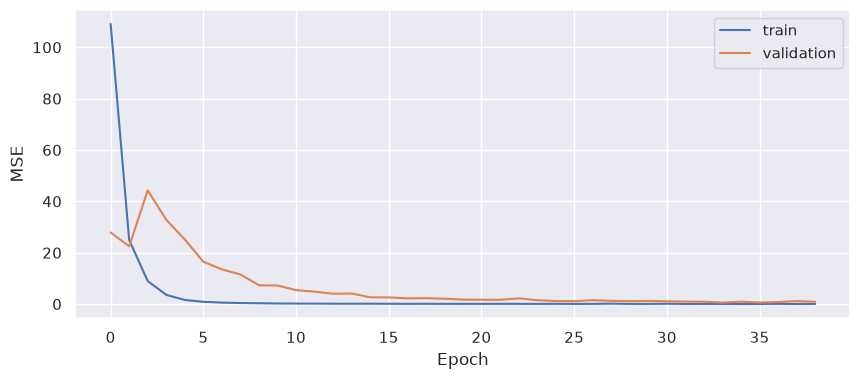

In [16]:
## Training history

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history.history["loss"], label="train")
ax.plot(history.history["val_loss"], label="validation")

ax.set_ylabel("MSE")
ax.set_xlabel("Epoch")
ax.legend()

plt.show()

In [17]:
## Predict test period

y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mae:.3f} °C")
print(f"RMSE = {rmse:.3f} °C")

41/41 [==============================] - 0s 654us/step
MAE  = 1.382 °C
RMSE = 1.473 °C


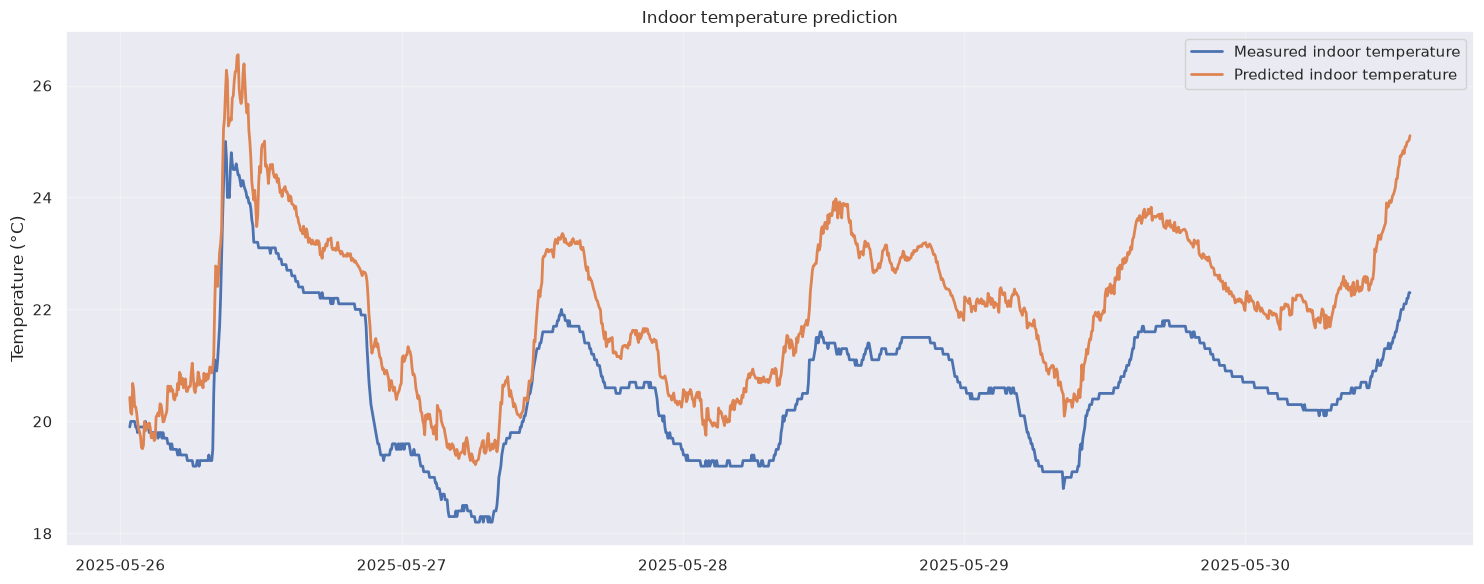

In [18]:
## Plot prediction on test period

test_time = df.iloc[val_end:]["datetime"]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    test_time,
    y_test,
    label="Measured indoor temperature",
    linewidth=2
)

ax.plot(
    test_time,
    y_pred,
    label="Predicted indoor temperature",
    linewidth=2
)

ax.set_title("Indoor temperature prediction")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

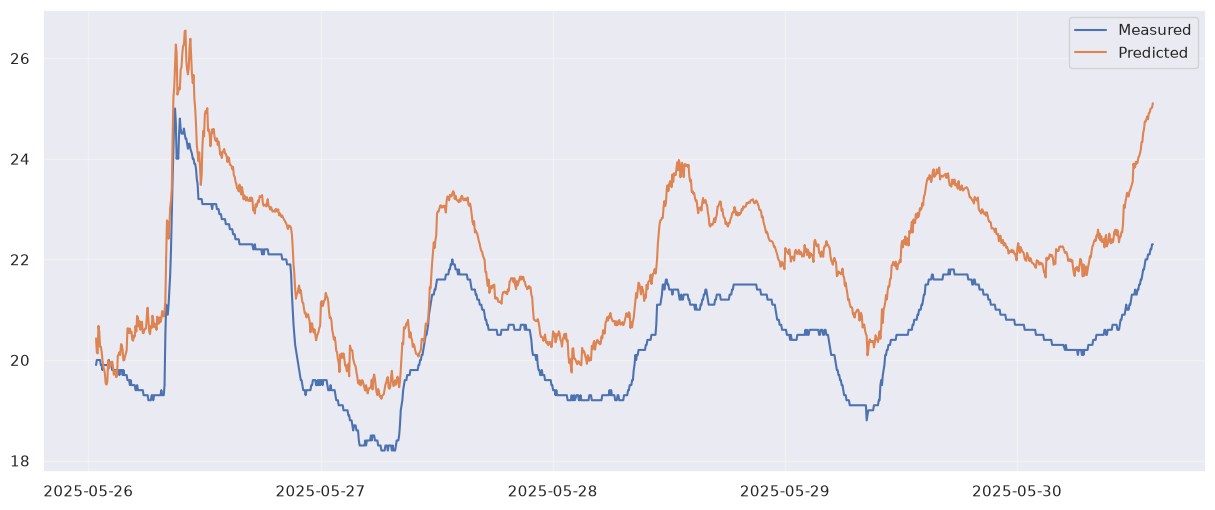

In [19]:
## Zoom into first week of test data

N = 7 * 24 * 12
# 7 days at 5-minute intervals

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    test_time.iloc[:N],
    y_test.iloc[:N],
    label="Measured"
)

ax.plot(
    test_time.iloc[:N],
    y_pred[:N],
    label="Predicted"
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [20]:
# Persistence baseline

y_pred_persistence = X_test["temp_in_lag_1"].values

mae = mean_absolute_error(y_test, y_pred_persistence)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_persistence))

print(f"Persistence MAE  = {mae:.4f} °C")
print(f"Persistence RMSE = {rmse:.4f} °C")

Persistence MAE  = 0.0387 °C
Persistence RMSE = 0.0866 °C


In [21]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train_scaled, y_train)

y_pred_lin = linreg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print(f"Linear Regression MAE  = {mae:.4f} °C")
print(f"Linear Regression RMSE = {rmse:.4f} °C")

Linear Regression MAE  = 0.0624 °C
Linear Regression RMSE = 0.0889 °C


In [22]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge MAE  = {mae:.4f} °C")
print(f"Ridge RMSE = {rmse:.4f} °C")

Ridge MAE  = 0.0625 °C
Ridge RMSE = 0.0891 °C


In [23]:
results = pd.DataFrame({
    "Model": [
        "Persistence",
        "Linear Regression",
        "Ridge",
        "Neural Network"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_persistence),
        mean_absolute_error(y_test, y_pred_lin),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_persistence)),
        np.sqrt(mean_squared_error(y_test, y_pred_lin)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE
0,Persistence,0.038739,0.086614
1,Linear Regression,0.062440,0.088872
2,Ridge,0.062495,0.089139
3,Neural Network,1.382470,1.472745


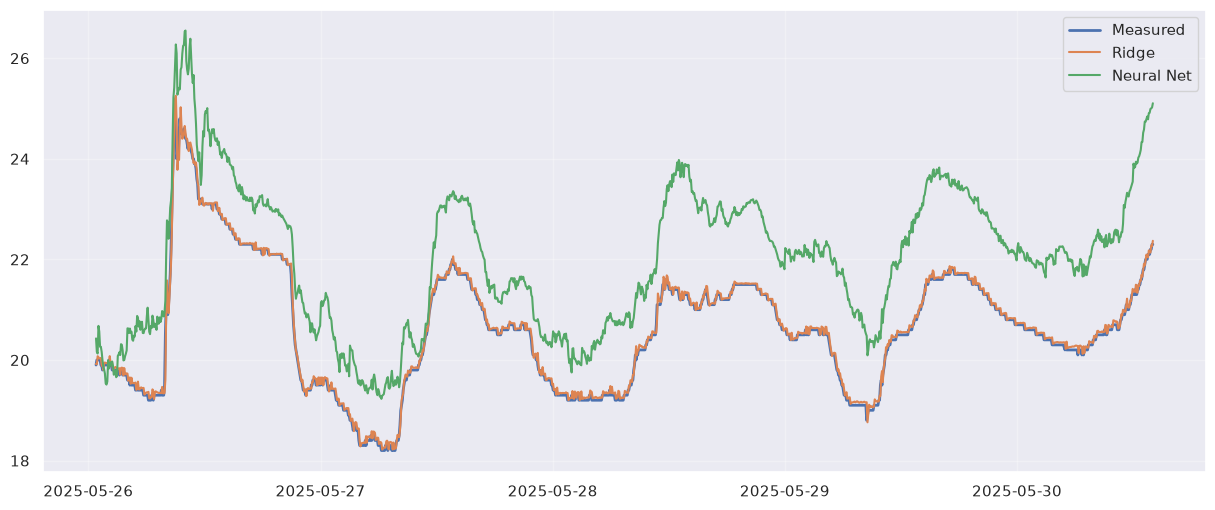

In [24]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    test_time.iloc[:N],
    y_test.iloc[:N],
    label="Measured",
    linewidth=2
)

ax.plot(
    test_time.iloc[:N],
    y_pred_ridge[:N],
    label="Ridge"
)

ax.plot(
    test_time.iloc[:N],
    y_pred[:N],
    label="Neural Net"
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()